# Phase 6: Pose Estimation
This notebook evaluates the pose estimation accuracy using the ADD metric.

In [2]:
import os
import math
import copy
import open3d as o3d
import numpy as np
from scipy.spatial.transform import Rotation as R
import pandas as pd
import re

def get_rotation_matrix_z(deg):
    """Creates a 3x3 rotation matrix for the Z-axis."""
    rad = math.radians(deg)
    c, s = math.cos(rad), math.sin(rad)
    return np.array([[c, -s, 0], 
                     [s,  c, 0], 
                     [0,  0, 1]])

def merge_multiview_scan(data_dir, initial_pos, initial_angle, box_size, viewpoint_indices=None, T_base2ob_yolo=None, remove_plane=False, do_crop=True):
    """Merges multiple view PCDs and optionally removes points below the detected plane."""
    pcd_files = [f for f in os.listdir(data_dir) if f.lower().endswith('.pcd')]

    def extract_number(filename):
        numbers = re.findall(r'\d+', filename)
        return int(numbers[0]) if numbers else 0
    
    pcd_files.sort(key=extract_number)
    
    if viewpoint_indices is not None:
        pcd_files = [f for f in pcd_files if extract_number(f) in viewpoint_indices]
        
    merged_pcd = o3d.geometry.PointCloud()
    
    if do_crop:
        obb = o3d.geometry.OrientedBoundingBox(
            center=np.array(initial_pos), 
            R=get_rotation_matrix_z(-initial_angle), 
            extent=np.array(box_size)
        )

    print(f"Found {len(pcd_files)} PCD files to merge. Processing...")

    for file_name in pcd_files:
        pcd = o3d.io.read_point_cloud(os.path.join(data_dir, file_name))
   
        if remove_plane:
            # 1. Detect the plane
            plane_model, inliers = pcd.segment_plane(distance_threshold=3.0, ransac_n=3, num_iterations=2000)
            [a, b, c, d] = plane_model

            # 2. Extract all points as a numpy array
            pts = np.asarray(pcd.points)

            # 3. Calculate distance to plane for every point: ax + by + cz + d
            distances = a * pts[:, 0] + b * pts[:, 1] + c * pts[:, 2] + d
            
            # 4. Create an index of points that are ABOVE the plane
            above_plane_indices = np.where(distances > 0.5)[0]
            pcd = pcd.select_by_index(above_plane_indices)

        # 5. Crop to the OBB and merge
        if do_crop:
            merged_pcd += pcd.crop(obb)
        else:
            merged_pcd += pcd

    return merged_pcd

def preprocess_normal(pcd, num_points=False, invert_normals=False, radius=2, max_nn=30):
    """Downsamples, estimates normals, and computes FPFH features."""
    if num_points:
        current_num_points = len(pcd.points)
        if current_num_points >= num_points:
            pcd_down = pcd.farthest_point_down_sample(num_points)
        else:
            pcd_down = o3d.geometry.PointCloud(pcd)
            num_to_pad = num_points - current_num_points
            indices = np.arange(current_num_points)
            pad_indices = np.random.choice(indices, size=num_to_pad, replace=True)
            orig_xyz = np.asarray(pcd.points)
            pad_xyz = orig_xyz[pad_indices]
            jitter = np.random.normal(0, 0.001, pad_xyz.shape)
            pad_xyz += jitter
            final_xyz = np.vstack((orig_xyz, pad_xyz))
            pcd_down.points = o3d.utility.Vector3dVector(final_xyz)
            if pcd.has_normals():
                orig_normals = np.asarray(pcd.normals)
                pad_normals = orig_normals[pad_indices]
                final_normals = np.vstack((orig_normals, pad_normals))
                pcd_down.normals = o3d.utility.Vector3dVector(final_normals)
    else:
        pcd_down = pcd
        
    avg_dist = np.mean(pcd_down.compute_nearest_neighbor_distance())
    pcd_down.estimate_normals(o3d.geometry.KDTreeSearchParamHybrid(radius=avg_dist * radius, max_nn=max_nn))
    normals = np.asarray(pcd_down.normals)
    
    if invert_normals:
        for i in range(len(normals)):
            if normals[i][2] < 0:
                normals[i] *= -1

    fpfh = o3d.pipelines.registration.compute_fpfh_feature(
        pcd_down, o3d.geometry.KDTreeSearchParamHybrid(radius=avg_dist * 5, max_nn=100))
    
    return pcd_down, fpfh

def run_global_registration_adaptive(source_down, target_down, source_fpfh, target_fpfh):
    max_attempts = 2
    best_fitness = -0.1
    best_inlier_rmse = 100.0
    best_result = None
    best_threshold = None 
    thresholds = [7, 5, 3]

    for attempt in range(max_attempts):
        for thr in thresholds:            
            result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
                source_down, target_down, source_fpfh, target_fpfh, 
                mutual_filter=True,
                max_correspondence_distance=thr,
                estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
                ransac_n=3, 
                checkers=[
                    o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.85),
                    o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(thr)
                ], 
                criteria=o3d.pipelines.registration.RANSACConvergenceCriteria(4000, 0.99)
            )
            if result.fitness > 0.8 and result.inlier_rmse < best_inlier_rmse:
                best_fitness = result.fitness
                best_inlier_rmse = result.inlier_rmse
                best_result = result
                best_threshold = thr
            if best_fitness > 0.8 and best_inlier_rmse < 3.0: 
                print(f"Excellent Global Fit Found at Threshold {best_threshold}")
                return best_result, best_threshold
            
    if best_result is None:
        print("Warning: RANSAC could not find a fit above 0.85 fitness.")
        return result, thr

    print(f"RANSAC Finished. Best Threshold: {best_threshold} | Fitness: {best_fitness:.4f}")
    return best_result, best_threshold

def run_local_refinement_adaptive(source, target, initial_trans=None, best_ransac_thr=10, method="point_to_plane"):
    if initial_trans is None:
        initial_trans = np.eye(4)
    multipliers = [1.0, 0.5, 0.2]
    thresholds = [best_ransac_thr * m for m in multipliers]
    best_result = None
    best_inlier_rmse = float('inf')
    
    if method == "point_to_plane":
        estimation_method = o3d.pipelines.registration.TransformationEstimationPointToPoint()
        print("Using Point-to-Plane ICP")
    else:
        estimation_method = o3d.pipelines.registration.TransformationEstimationPointToPoint()
        print("Using Point-to-Point ICP")
    
    print(f"{'Threshold':<12} | {'Fitness':<12} | {'RMSE':<12}")
    print("-" * 45)
    for thr in thresholds:
        reg_icp = o3d.pipelines.registration.registration_icp(
            source, target, thr, initial_trans,
            estimation_method,
            o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=200)
        )
        print(f"{thr:<12.2f} | {reg_icp.fitness:<12.4f} | {reg_icp.inlier_rmse:<12.4f}")
        if reg_icp.fitness > 0.85 and reg_icp.inlier_rmse < best_inlier_rmse:
            best_inlier_rmse = reg_icp.inlier_rmse
            best_result = reg_icp
    return best_result if best_result is not None else reg_icp

def calculate_add(source_cloud, T_est, T_gt):
    """
    Calculates the Average Distance of Model Points (ADD) using the L2 norm.
    ADD = 1/|M| sum ||(T_est * x) - (T_gt * x)||_2
    """
    points = np.asarray(source_cloud.points)
    ones = np.ones((points.shape[0], 1))
    points_homo = np.hstack([points, ones])
    
    # Apply Estimated Transformation
    est_points = (T_est @ points_homo.T).T[:, :3]
    
    # Apply Ground Truth Transformation
    gt_points = (T_gt @ points_homo.T).T[:, :3]
    
    # Calculate L2 norm (Euclidean distance) for each point
    distances = np.linalg.norm(est_points - gt_points, axis=1)
    
    # ADD is the mean of these distances
    add_metric = np.mean(distances)
    
    return add_metric


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


### 1. Configuration

In [90]:
# --- 1. Configuration ---
NUMBER_OF_POINTS = 40000
EXPERIMENT = "test_9_simulation_3"
WORKPIECE = "TH0011AV"

SOURCE_PATH = f"workpiece/{WORKPIECE}/workpiece.stl" # CAD STL model
DATA_DIR = f"pcd_data/testing_data/{EXPERIMENT}/{WORKPIECE}" # Multiview scans

# Manually set which viewpoints to merge. Leave as None to process all.
VIEWPOINT_INDICES = [] 

# Dummy Initialization for Simulation Data
T_base2ob_yolo = np.eye(4)
YOLO_POS = [5.0, -3.0, 2.0]  # Off by 5mm in X, 3mm in Y
YOLO_ANGLE = 5.0               # Off by 5 degrees
CROP_BOX = [1000, 1000, 1000] # Large crop box to avoid cutting off dummy data

# Ground Truth Pose (Currently set to dummy identity matrix 0,0,0,0,0,0)
T_gt = np.eye(4)


### 2. Data Preparation & Merging

In [ ]:
# --- 2. Data Preparation ---
mesh = o3d.io.read_triangle_mesh(SOURCE_PATH)
mesh.compute_vertex_normals()

# CAD Model point cloud
source_cloud = mesh.sample_points_uniformly(number_of_points=NUMBER_OF_POINTS)

# Load and Merge specific viewpoints
full_target_cloud = merge_multiview_scan(DATA_DIR, YOLO_POS, YOLO_ANGLE, CROP_BOX, viewpoint_indices=VIEWPOINT_INDICES, T_base2ob_yolo=T_base2ob_yolo, remove_plane=False, do_crop=False)

world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=100.0, origin=[0, 0, 0])
# o3d.visualization.draw_geometries([full_target_cloud, mesh, world_frame], window_name="Merged Target Cloud")

# Manual Initial Guess
T_extra = np.eye(4)
r = R.from_euler('z', 0, degrees=True)
T_extra[:3, :3] = r.as_matrix()
T_initial_guess = T_base2ob_yolo @ T_extra

# Preprocess Normal and FPFH
source_cloud_transformed = copy.deepcopy(source_cloud).transform(T_initial_guess)
source_down, source_fpfh = preprocess_normal(source_cloud_transformed)
target_down, target_fpfh = preprocess_normal(full_target_cloud, num_points=40000, invert_normals=True)

source_down.paint_uniform_color([1, 0, 0])
target_down.paint_uniform_color([0, 0.651, 0.929])
# o3d.visualization.draw_geometries([target_down, source_down], window_name="Processed Initial Target vs Source")


Found 432 PCD files to merge. Processing...


### 2.5 Initial Guess ADD Metric (Before Registration)

In [53]:
# --- 2.5 Initial ADD ACCURACY MEASUREMENT ---
print("="*30)
initial_add_value = calculate_add(source_cloud, T_initial_guess, T_gt)
print(f"Initial Pose Accuracy (ADD) before registration: {initial_add_value:.4f} mm")
print("="*30)


Initial Pose Accuracy (ADD) before registration: 0.0000 mm


### 3. Global Alignment (RANSAC)

In [ ]:
# --- 3. Global Alignment (RANSAC) ---
print("Step 2: Running RANSAC Global Registration...")
ransac_res, best_thr = run_global_registration_adaptive(source_down, target_down, source_fpfh, target_fpfh)
print(ransac_res)

# Visualize RANSAC result
source_temp = copy.deepcopy(source_down)
source_temp.transform(ransac_res.transformation)
source_temp.paint_uniform_color([1, 0, 0])
target_down.paint_uniform_color([0, 0.651, 0.929])
# o3d.visualization.draw_geometries([source_temp, target_down], window_name="RANSAC Result")


Step 2: Running RANSAC Global Registration...
[Open3D WARNING] Too few correspondences (19) after mutual filter, fall back to original correspondences.
[Open3D WARNING] Too few correspondences (19) after mutual filter, fall back to original correspondences.
[Open3D WARNING] Too few correspondences (19) after mutual filter, fall back to original correspondences.
[Open3D WARNING] Too few correspondences (19) after mutual filter, fall back to original correspondences.
[Open3D WARNING] Too few correspondences (19) after mutual filter, fall back to original correspondences.
[Open3D WARNING] Too few correspondences (19) after mutual filter, fall back to original correspondences.
RegistrationResult with fitness=0.000000e+00, inlier_rmse=0.000000e+00, and correspondence_set size of 0
Access transformation to get result.


### 4. Local Alignment (ICP) & ADD Metric

In [55]:
# --- 4. Local Alignment (ICP) ---
print("Step 3: Running ICP Local Refinement...")
icp_res = run_local_refinement_adaptive(source_down, target_down, method="point_to_plane") #icp only
print(icp_res)

# --- 5. Extract Final Results ---
fine_correction_transformation = icp_res.transformation 
T_est = np.dot(fine_correction_transformation, T_initial_guess) 

print("="*30)
print(f"Estimated Position: {T_est[:3, 3]}")
print(f"Estimated Orientation Matrix:\n{T_est[:3, :3]}")
print(f"Fitness: {icp_res.fitness:.4f}")
print(f"RMSE: {icp_res.inlier_rmse:.4f}")

# --- 6. ADD ACCURACY MEASUREMENT ---
print("="*30)
add_value = calculate_add(source_cloud, T_est, T_gt)
print(f"Pose Estimation Accuracy (ADD): {add_value:.4f} mm")

# --- 7. Final Visualization ---
source_est = copy.deepcopy(source_cloud).transform(T_est)
source_est.paint_uniform_color([1, 0, 0])         # Red: Estimated Pose

source_gt = copy.deepcopy(source_cloud).transform(T_gt)
source_gt.paint_uniform_color([0, 1, 0])         # Green: Ground Truth Pose

full_target_cloud.paint_uniform_color([0, 0.65, 0.93])   # Blue: Scanned Data

o3d.visualization.draw_geometries([source_est, source_gt, full_target_cloud], window_name=f"Pose Estimation (ADD: {add_value:.4f})")


Step 3: Running ICP Local Refinement...
Using Point-to-Plane ICP
Threshold    | Fitness      | RMSE        
---------------------------------------------
10.00        | 0.9375       | 1.8679      
5.00         | 0.8970       | 1.0537      
2.00         | 0.8639       | 0.8157      
RegistrationResult with fitness=8.639250e-01, inlier_rmse=8.157409e-01, and correspondence_set size of 34557
Access transformation to get result.
Estimated Position: [ 1.36154587  2.03238529 -0.90639037]
Estimated Orientation Matrix:
[[ 0.99987593 -0.01153041 -0.01073162]
 [ 0.01147769  0.99992182 -0.00496162]
 [ 0.01078799  0.00483783  0.9999301 ]]
Fitness: 0.8639
RMSE: 0.8157
Pose Estimation Accuracy (ADD): 2.4531 mm


### 5. Batch Processing (Multiple Workpieces)
Run the pipeline on an entire list of workpieces automatically without popping up visualization windows.

In [6]:
# ==========================================
# BATCH PROCESSING MULTIPLE WORKPIECES
# ==========================================
import time
import numpy as np
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R

# Define the list of workpieces you want to evaluate
BATCH_WORKPIECES = ["TH0022AV"]
# BATCH_WORKPIECES = ["TH0011AV", "TH0012AV", "TH0021AV", "TH0022AV", "TH0031AV", "TH0032AV"]
# BATCH_WORKPIECES = ["TH0011AV", "TH0012AV", "TH0021AV", "TH0022AV", "TH0031AV", "TH0032AV", "TH0041AV", "TH0042AV", "TH0051AV", "TH0052AV", "TH0061AV", "TH0062AV", "TH0071AV", "TH0072AV"]
ENABLE_VISUALIZATION = True # Set to False if you want it to run headlessly
USE_RANSAC = False # Set to True to use RANSAC + ICP, False for ICP only
EXPERIMENT = "test_9_simulation_3"
NUMBER_OF_POINTS = 40000
FPS_NUMBER = 7500

# Dummy Initialization for Simulation Data
YOLO_POS = [5.0, -3.0, 2.0]
YOLO_ANGLE = 5
# YOLO_POS = [0, 0, 0] #[5.0, -3.0, 2.0]
# YOLO_ANGLE = 0 # 5

# --- AUTOMATED VIEWPOINT SELECTION ---
# Set to a specific list of viewpoints (e.g., [80]) to test the same viewpoint across ALL workpieces.
# Set to None to automatically use the optimal sequence for each workpiece below.

# FIXED_VIEWPOINT_OVERRIDE = None   # Default: None
FIXED_VIEWPOINT_OVERRIDE = [37, 128, 28, 46, 67, 206, 71, 53, 70, 61, 52, 68]

# GRID LIKE
# FIXED_VIEWPOINT_OVERRIDE = [80]
# FIXED_VIEWPOINT_OVERRIDE = [80, 88]
# FIXED_VIEWPOINT_OVERRIDE = [80, 85, 90]
# FIXED_VIEWPOINT_OVERRIDE = [80, 84, 88, 92] 
# FIXED_VIEWPOINT_OVERRIDE = [80, 82, 84, 86, 88, 90, 92, 94]
# FIXED_VIEWPOINT_OVERRIDE = [80, 81, 83, 84, 85, 87, 88, 89, 91, 92, 93, 95]


# FIXED_VIEWPOINT_OVERRIDE = [0, 4, 8, 12] # 5 deg
# FIXED_VIEWPOINT_OVERRIDE = [16, 20, 24, 28] # 10 deg
# FIXED_VIEWPOINT_OVERRIDE = [32, 36, 40, 44] # 15 deg
# FIXED_VIEWPOINT_OVERRIDE = [48, 52, 56, 60] # 20 deg
# FIXED_VIEWPOINT_OVERRIDE = [64, 68, 72, 76] # 25 deg
# FIXED_VIEWPOINT_OVERRIDE = [80, 84, 88, 92] # 30 deg
# FIXED_VIEWPOINT_OVERRIDE = [96, 100, 104, 108] # 35 deg
# FIXED_VIEWPOINT_OVERRIDE = [112, 116, 120, 124] # 40 deg
# FIXED_VIEWPOINT_OVERRIDE = [128, 132, 136, 140] # 45 deg


# Set how many views you are testing (1, 4, 8, or 12)
TARGET_VIEW_COUNT = 12

VIEWPOINT_LIBRARY = {
    1: [
        # GRASP GT
        # [427], [418], [424], [67], [201], [422], [137], [264], [281], [424], [429], [281], [141], [423]
        # GRASP INFERENCE
        # [430], [423], [424], [210], [211], [424], [136], [424], [280], [424], [137], [423], [425], [422]
        # FILTER 0.8
        # [4], [40], [175], [155], [1], [145], [146], [21], [7], [2], [1], [4], [7], [12]
        # GRASP GT UPDATED
        # [169], [40], [175], [155], [1], [156], [302], [21], [299], [4], [289], [292], [5], [249]
        # GRASP GT UPDATED 2
        # [47], [27], [21], [32], [29], [43], [26], [18], [50], [22], [57], [27], [43], [18]
        # GRASP GT UPDATED 2 INFERENCE
        # [29], [18], [18], [22], [25], [18], [46], [35], [34], [29], [34], [18], [34], [19]
        # GRASP NOISE NEW
        [54], [18], [42], [28], [29], [46]
    ],
    2: [
        # FILTER 0.8
        # [4, 16], [4, 160], [175, 21], [79, 13], [1, 151], [156, 145], [7, 302], [19, 11], [7, 0], [2, 313], [7, 289], [3, 12], [7, 145], [12, 116]
        # GRASP GT UPDATED
        # [169, 16], [160, 40], [175, 340], [155, 79], [1, 151], [156, 19], [302, 311], [21, 19], [299, 50], [4, 174], [289, 27], [292, 288], [5, 189], [249, 50]
        # GRASP GT UPDATED 2
        # [34, 219], [18, 27], [21, 30], [13, 32], [13, 104], [18, 43], [26, 50], [18, 58], [50, 41], [22, 46], [46, 53], [18, 27], [34, 43], [18, 26]    
        # GRASP GT UPDATED 2 INFERENCE
        # [29, 70], [18, 57], [26, 33], [22, 41], [25, 175], [18, 42], [46, 215], [35, 42], [34, 58], [29, 54], [34, 57], [18, 26], [34, 58], [19, 42] 
        # GRASP NOISE NEW
        [54, 254], [18, 74], [42, 66], [37, 67], [25, 67], [46, 214]
    ],
    3: [
        # FILTER 0.8
        # [4, 7, 16], [4, 160, 40], [30, 21, 175], [79, 155, 13], [1, 31, 2], [156, 145, 1], [146, 311, 302], [19, 43, 295], [299, 50, 7], [7, 2, 15], [1, 7, 3], [145, 292, 12], [5, 145, 26], [12, 116, 32]
        # GRASP GT UPDATED
        # [169, 34, 16], [40, 160, 6], [340, 175, 30], [74, 79, 155], [2, 151, 155], [156, 145, 292], [146, 311, 335], [19, 21, 43], [299, 50, 20], [17, 4, 174], [289, 27, 7], [292, 157, 12], [5, 189, 7], [249, 116, 175]
        # GRASP GT UPDATED 2
        # [34, 89, 47], [18, 27, 38], [21, 30, 91], [13, 32, 28], [13, 104, 29], [18, 43, 53], [43, 50, 26], [18, 58, 174], [26, 50, 41], [22, 46, 18], [22, 46, 57], [18, 42, 27], [34, 57, 43], [18, 26, 22]
        # GRASP GT UPDATED 2 INFERENCE
        # [29, 70, 50], [18, 57, 29], [26, 33, 18], [22, 41, 26], [25, 175, 38], [18, 41, 30], [34, 57, 46], [35, 42, 46], [34, 58, 66], [18, 41, 29], [34, 57, 26], [18, 26, 33], [34, 58, 55], [19, 41, 29]
        # GRASP NOISE NEW
        [38, 142, 105], [18, 73, 142], [42, 66, 118], [28, 130, 50], [25, 68, 65], [46, 69, 105]
    ],
    4: [
        # GRASP GT
        # [142, 286, 254, 238], [277, 117, 390, 101], [424, 136, 137, 263], [67, 139, 55, 209], [132, 204, 192, 70], [422, 423, 391, 374], [137, 281, 104, 393], [264, 121, 408, 423], [281, 137, 264, 394], [424, 280, 137, 408], [282, 410, 137, 267], [281, 137, 282, 249], [394, 250, 377, 378], [282, 122, 249, 410]
        # GRASP INFERENCE
        #[286, 430, 142, 270], [423, 279, 135, 263], [424, 136, 280, 425], [138, 210, 137, 209], [215, 143, 71, 131], [424, 408, 264, 136], [136, 280, 264, 408], [424, 264, 408, 120], [280, 136, 424, 137], [424, 264, 120, 408], [430, 286, 142, 270], [424, 136, 280, 423], [425, 281, 137, 409], [431, 143, 287, 271]
        # FILTER 0.8
        # [7, 28, 4, 16], [164, 12, 145, 40], [175, 340, 299, 161], [79, 155, 13, 76], [1, 151, 12, 87], [156, 1, 293, 145], [146, 311, 299, 335], [19, 295, 158, 11], [7, 0, 5, 31], [7, 2, 14, 295], [7, 1, 289, 26], [145, 7, 3, 12], [1, 5, 7, 157], [12, 116, 32, 164]
        # GRASP GT UPDATED
        # [169, 16, 326, 34], [160, 6, 40, 307], [340, 175, 156, 30], [79, 74, 155, 164], [1, 151, 73, 31], [156, 145, 164, 317], [146, 311, 335, 299], [21, 147, 19, 43], [299, 50, 7, 239], [4, 46, 14, 37], [289, 346, 7, 3], [292, 12, 288, 4], [5, 189, 43, 337], [249, 50, 116, 269]
        # GRASP GT UPDATED 2
        # [18, 89, 47, 182], [18, 27, 38, 47], [21, 30, 91, 49], [13, 32, 28, 94], [26, 115, 13, 104], [18, 43, 53, 46], [26, 50, 46, 183], [174, 310, 18, 58], [26, 19, 50, 90], [22, 46, 34, 26], [22, 46, 57, 50], [18, 41, 27, 35], [34, 57, 19, 43], [22, 189, 18, 26]
        # GRASP GT UPDATED 2 INFERENCE
        # [42, 50, 29, 86], [18, 41, 29, 54], [26, 50, 18, 74], [26, 103, 22, 41], [25, 175, 38, 68], [18, 41, 30, 22], [34, 74, 46, 215], [34, 42, 35, 201], [34, 58, 66, 217], [29, 54, 18, 41], [26, 18, 34, 57], [18, 58, 30, 71], [34, 58, 46, 55], [19, 41, 29, 38]
        # GRASP NOISE NEW
        [38, 142, 105, 98], [18, 73, 142, 103], [42, 66, 126, 246], [28, 46, 50, 128], [25, 67, 143, 65], [46, 214, 99, 106]
    ],
    8: [
        # GRASP GT
        #[281, 137, 410, 138, 216, 427, 408, 169], [286, 271, 414, 222, 413, 111, 78, 333], [424, 263, 265, 408, 425, 137, 410, 247], [67, 139, 55, 126, 209, 65, 53, 43], [199, 139, 67, 126, 66, 201, 31, 20], [424, 136, 423, 422, 374, 392, 391, 215], [281, 408, 409, 104, 393, 376, 73, 249], [431, 287, 264, 400, 416, 408, 121, 120], [281, 137, 138, 266, 394, 264, 90, 393], [424, 280, 266, 137, 408, 426, 250, 217], [282, 410, 395, 267, 234, 346, 219, 363], [429, 430, 269, 413, 254, 351, 109, 398], [141, 142, 430, 383, 413, 237, 78, 189], [249, 122, 410, 282, 235, 91, 426, 106]
        # GRASP INFERENCE
        # [142, 429, 286, 430, 285, 269, 413, 109], [281, 425, 137, 138, 265, 409, 346, 74], [424, 280, 408, 136, 120, 264, 281, 425], [138, 210, 209, 211, 137, 66, 65, 67], [211, 139, 55, 127, 199, 175, 43, 187], [136, 280, 424, 408, 137, 264, 248, 392], [136, 280, 408, 120, 392, 409, 264, 121], [281, 424, 408, 280, 120, 264, 137, 248], [280, 136, 424, 408, 281, 137, 264, 248], [424, 136, 120, 408, 280, 264, 392, 104], [137, 265, 409, 121, 425, 281, 249, 393], [424, 136, 280, 408, 264, 423, 279, 120], [425, 281, 409, 265, 362, 121, 378, 74], [431, 143, 287, 271, 399, 127, 415, 416]
        # FILTER 0.8
        # [4, 169, 16, 151, 36, 320, 28, 7], [4, 12, 145, 40, 164, 160, 6, 156], [175, 340, 151, 0, 21, 29, 327, 288], [13, 164, 155, 79, 147, 74, 24, 76], [1, 6, 87, 12, 20, 73, 16, 155], [145, 156, 7, 19, 1, 293, 24, 317], [7, 335, 145, 293, 167, 302, 35, 186], [295, 158, 19, 21, 173, 20, 176, 43], [7, 31, 145, 23, 0, 20, 24, 178], [17, 314, 7, 174, 1, 4, 295, 15], [7, 1, 289, 346, 37, 0, 3, 27], [4, 288, 7, 145, 12, 3, 170, 289], [1, 7, 5, 157, 20, 44, 33, 26], [12, 164, 175, 116, 92, 5, 32, 146]
        # GRASP GT UPDATED
        # [326, 320, 169, 16, 327, 146, 4, 14], [40, 160, 164, 307, 6, 154, 333, 48], [175, 21, 340, 30, 327, 288, 299, 161], [164, 74, 155, 13, 79, 89, 14, 172], [151, 1, 87, 155, 73, 31, 2, 201], [156, 145, 293, 1, 24, 317, 292, 19], [335, 342, 146, 311, 302, 299, 18, 73], [147, 295, 173, 21, 19, 43, 158, 11], [299, 290, 7, 0, 166, 50, 221, 42], [4, 15, 295, 174, 2, 314, 17, 37], [289, 346, 7, 1, 27, 3, 37, 175], [12, 292, 195, 288, 149, 289, 157, 313], [5, 26, 337, 189, 43, 33, 292, 157], [249, 50, 235, 157, 357, 269, 403, 116]
        # GRASP GT UPDATED 2
        # [18, 89, 47, 182, 95, 135, 123, 65], [18, 185, 30, 38, 19, 171, 135, 47], [22, 30, 21, 78, 85, 109, 121, 97], [13, 32, 28, 35, 19, 85, 89, 94], [13, 104, 26, 115, 49, 55, 40, 70], [18, 43, 165, 61, 19, 42, 46, 119], [46, 86, 50, 43, 91, 67, 137, 65], [18, 186, 174, 310, 163, 58, 47, 55], [26, 50, 19, 362, 49, 90, 134, 109], [22, 46, 18, 26, 33, 42, 37, 78], [57, 33, 53, 223, 75, 83, 137, 97], [18, 42, 30, 181, 27, 51, 39, 62], [34, 57, 19, 43, 111, 119, 141, 103], [18, 26, 22, 63, 33, 217, 135, 189]
        # GRASP GT UPDATED 2 INFERENCE
        # [29, 214, 50, 43, 135, 126, 51, 137], [18, 42, 29, 54, 34, 185, 33, 73], [26, 18, 33, 74, 87, 143, 139, 98], [26, 175, 25, 43, 22, 41, 34, 53], [25, 43, 38, 175, 49, 67, 62, 68], [18, 41, 30, 55, 33, 58, 19, 42], [34, 74, 46, 87, 65, 107, 137, 33], [35, 42, 34, 58, 46, 39, 79, 55], [34, 58, 66, 217, 111, 119, 141, 86], [30, 198, 33, 41, 19, 330, 29, 87], [18, 26, 57, 34, 82, 121, 119, 241], [18, 26, 19, 57, 30, 71, 33, 251], [34, 58, 46, 87, 127, 135, 50, 137], [19, 41, 18, 42, 29, 39, 97, 89]
        # GRASP NOISE NEW
        [38, 254, 113, 105, 134, 141, 127, 101], [18, 73, 62, 103, 130, 123, 137, 133], [53, 253, 131, 89, 135, 126, 283, 418], [37, 67, 28, 46, 128, 206, 61, 52], [25, 68, 65, 130, 61, 211, 64, 143], [46, 69, 106, 65, 133, 111, 137, 395]
    ],
    12: [
        # GRASP GT
        #[281, 137, 408, 410, 216, 233, 200, 411, 427, 185, 346, 169], [418, 417, 401, 114, 243, 355, 386, 82, 387, 226, 307, 67], [424, 425, 137, 265, 281, 263, 408, 136, 247, 119, 392, 391], [139, 67, 209, 55, 199, 65, 126, 137, 198, 43, 53, 186], [199, 201, 139, 67, 187, 31, 20, 151, 91, 80, 9, 92], [416, 400, 143, 240, 413, 113, 384, 109, 398, 253, 237, 48], [408, 104, 137, 376, 393, 409, 105, 73, 362, 251, 235, 21], [264, 423, 424, 407, 121, 120, 408, 104, 265, 232, 248, 231], [281, 137, 394, 264, 393, 392, 233, 391, 266, 56, 248, 90], [280, 137, 424, 426, 409, 281, 266, 408, 233, 376, 248, 250], [418, 274, 131, 257, 385, 402, 242, 354, 370, 98, 210, 321], [429, 281, 282, 283, 426, 234, 106, 411, 252, 91, 220, 204], [141, 413, 430, 142, 109, 383, 237, 205, 189, 317, 319, 318], [282, 122, 249, 410, 138, 106, 426, 393, 235, 91, 75, 219]
        # GRASP INFERENCE
        # [286, 285, 430, 429, 142, 269, 413, 270, 397, 253, 109, 381], [281, 425, 137, 426, 138, 378, 362, 90, 346, 202, 58, 345], [280, 424, 408, 120, 264, 425, 248, 136, 392, 104, 265, 137], [210, 138, 66, 209, 211, 137, 67, 139, 127, 198, 54, 65], [211, 127, 199, 187, 55, 115, 43, 103, 175, 163, 92, 176], [424, 264, 408, 280, 136, 120, 137, 281, 425, 121, 392, 104], [136, 408, 280, 137, 264, 424, 120, 409, 248, 121, 392, 265], [281, 425, 408, 120, 264, 424, 392, 137, 265, 280, 248, 104], [424, 136, 280, 264, 281, 408, 120, 137, 121, 409, 265, 248], [408, 280, 424, 264, 136, 120, 423, 248, 392, 135, 119, 263], [425, 281, 137, 424, 408, 280, 264, 265, 121, 409, 120, 393], [279, 135, 423, 278, 263, 119, 407, 422, 134, 406, 247, 231], [425, 138, 265, 121, 409, 137, 281, 105, 393, 249, 362, 378], [422, 278, 134, 135, 279, 406, 407, 375, 231, 423, 391, 359]
        # FILTER 0.8
        # [4, 169, 28, 34, 151, 288, 7, 16, 36, 3, 171, 146], [164, 12, 145, 40, 148, 160, 4, 154, 13, 5, 16, 295], [299, 175, 340, 161, 151, 1, 10, 306, 8, 30, 198, 19], [155, 76, 79, 24, 74, 164, 13, 147, 179, 18, 145, 89], [1, 31, 73, 20, 2, 150, 12, 151, 100, 155, 87, 86], [156, 19, 145, 7, 3, 11, 1, 40, 15, 24, 164, 317], [7, 146, 335, 299, 145, 166, 167, 302, 32, 293, 35, 186], [295, 19, 173, 21, 1, 11, 161, 171, 4, 176, 24, 158], [7, 145, 5, 221, 299, 50, 0, 20, 153, 239, 23, 290], [7, 2, 15, 295, 1, 313, 17, 28, 6, 14, 37, 46], [289, 27, 1, 7, 3, 26, 28, 290, 296, 321, 37, 48], [3, 28, 7, 288, 292, 157, 4, 1, 313, 145, 12, 18], [7, 157, 292, 1, 36, 44, 3, 25, 160, 5, 145, 26], [164, 157, 12, 116, 32, 5, 44, 17, 9, 162, 296, 146]
        # GRASP GT UPDATED
        # [326, 169, 16, 4, 14, 327, 34, 171, 3, 152, 320, 36], [160, 40, 5, 307, 333, 312, 295, 30, 6, 164, 320, 174], [175, 340, 299, 30, 327, 161, 21, 333, 156, 288, 19, 198], [79, 74, 13, 164, 14, 155, 147, 172, 35, 151, 24, 57], [2, 20, 12, 87, 151, 155, 73, 100, 1, 201, 31, 98], [156, 164, 317, 19, 1, 198, 145, 11, 7, 305, 40, 321], [302, 311, 335, 166, 145, 7, 146, 73, 80, 170, 4, 46], [147, 21, 173, 11, 290, 43, 19, 171, 191, 39, 161, 300], [5, 299, 239, 20, 221, 178, 42, 211, 23, 50, 0, 24], [4, 15, 37, 14, 2, 314, 7, 17, 174, 295, 46, 6], [1, 346, 289, 7, 28, 321, 196, 3, 185, 175, 23, 48], [292, 31, 12, 195, 170, 2, 7, 289, 152, 288, 3, 4], [5, 189, 26, 33, 292, 157, 43, 337, 6, 145, 10, 160], [249, 50, 116, 269, 235, 96, 215, 175, 357, 5, 303, 264]
        # GRASP GT UPDATED 2
        # [18, 89, 47, 182, 95, 135, 219, 82, 137, 65, 101, 126], [38, 30, 19, 185, 18, 27, 135, 47, 137, 33, 111, 101], [21, 30, 39, 191, 91, 81, 135, 78, 245, 109, 114, 121], [28, 35, 13, 32, 29, 94, 26, 163, 85, 128, 53, 59], [26, 104, 29, 46, 13, 55, 61, 68, 65, 131, 64, 70], [46, 165, 18, 314, 43, 35, 119, 79, 19, 251, 121, 81], [43, 33, 26, 67, 103, 126, 137, 99, 142, 278, 283, 258], [18, 58, 174, 310, 163, 186, 79, 39, 47, 119, 267, 83], [26, 50, 41, 49, 119, 77, 101, 111, 425, 258, 109, 134], [22, 173, 18, 42, 34, 26, 87, 47, 117, 237, 137, 65], [57, 33, 53, 46, 75, 98, 105, 97, 117, 111, 137, 83], [42, 162, 30, 39, 27, 18, 53, 95, 137, 49, 91, 51], [34, 43, 39, 46, 19, 409, 111, 103, 141, 278, 241, 137], [22, 63, 18, 26, 33, 217, 135, 415, 165, 125, 99, 137]
        # GRASP GT UPDATED 2 INFERENCE
        # [19, 41, 18, 42, 29, 39, 97, 89], [18, 57, 29, 54, 33, 42, 34, 41, 79, 87, 67, 91], [26, 33, 18, 139, 87, 95, 118, 287, 121, 19, 135, 143], [25, 175, 22, 125, 98, 103, 34, 41, 26, 56, 70, 65], [25, 175, 38, 67, 49, 116, 65, 50, 140, 133, 68, 62], [30, 22, 19, 41, 33, 42, 18, 73, 119, 62, 29, 103], [34, 218, 46, 215, 65, 107, 407, 110, 81, 137, 139, 195], [34, 201, 46, 183, 177, 42, 35, 123, 79, 230, 135, 397], [66, 58, 34, 217, 141, 263, 111, 86, 81, 121, 98, 122], [30, 55, 18, 41, 19, 330, 33, 89, 397, 87, 65, 107], [18, 26, 57, 34, 121, 81, 103, 82, 235, 241, 122, 98], [19, 26, 30, 71, 18, 41, 49, 251, 39, 79, 34, 123], [46, 39, 50, 58, 135, 94, 82, 137, 127, 119, 107, 209], [29, 54, 34, 42, 19, 41, 18, 58, 97, 89, 62, 103]
        # GRASP NOISE NEW
        [54, 254, 113, 105, 134, 125, 127, 141, 118, 407, 101, 97], [18, 122, 42, 113, 119, 253, 133, 137, 269, 142, 130, 38], [37, 253, 131, 283, 135, 383, 105, 418, 126, 245, 125, 263], [37, 128, 28, 46, 67, 206, 71, 53, 70, 61, 52, 68], [25, 68, 64, 143, 65, 130, 61, 67, 134, 70, 211, 133], [46, 214, 65, 106, 133, 111, 137, 109, 99, 121, 126, 103]
    ]
}
CROP_BOX = [1000, 1000, 1000]

T_base2ob_yolo = np.eye(4)
T_base2ob_yolo[:3, :3] = R.from_euler('z', YOLO_ANGLE, degrees=True).as_matrix()
T_base2ob_yolo[:3, 3] = YOLO_POS
T_gt = np.eye(4)

batch_results = []

print(f"Starting batch pose estimation for {len(BATCH_WORKPIECES)} workpieces...")

for idx_wp, wp in enumerate(BATCH_WORKPIECES):
    if FIXED_VIEWPOINT_OVERRIDE is not None:
        VIEWPOINT_INDICES = FIXED_VIEWPOINT_OVERRIDE
    else:
        VIEWPOINT_INDICES = VIEWPOINT_LIBRARY[TARGET_VIEW_COUNT][idx_wp]
    print(f"\nEvaluating {TARGET_VIEW_COUNT} Views: {VIEWPOINT_INDICES}")
    print(f"\n{'='*40}")
    print(f"Processing Workpiece: {wp}")
    print(f"{'='*40}")
    
    start_time = time.time()
    # Lock the random seed so that any point cloud padding jitter is 100% identical every run
    np.random.seed(42)
    o3d.utility.random.seed(42)
    
    # Paths
    source_path = f"workpiece/{wp}/workpiece.stl"

    # data_dir = f"pcd_data/testing_data/{EXPERIMENT}/{wp}"
    # data_dir = f"viewpoints_candidate/testing_data/{EXPERIMENT}/{wp}"
    data_dir = f"simulation/{EXPERIMENT}/{wp}"
    
    if not os.path.exists(source_path) or not os.path.exists(data_dir):
        print(f"Skipping {wp} - Missing STL or PCD folder!")
        continue
        
    # 1. Load CAD
    mesh = o3d.io.read_triangle_mesh(source_path) #stl
    mesh.compute_vertex_normals()
    source_cloud = mesh.sample_points_uniformly(number_of_points=NUMBER_OF_POINTS)
    
    # source_cloud = o3d.io.read_point_cloud(f"simulation/test_9_simulation_3/{wp}/viewpoint_simulated_noise_averaged.pcd") 
    # source_cloud.estimate_normals()

    # # manual
    # source_path = r"simulation/test_9_simulation_3/TH0011AV/viewpoint_simulated_noise_averaged.pcd"
    # source_cloud = o3d.io.read_point_cloud(source_path)



    # 2. Load Scans
    full_target_cloud = merge_multiview_scan(data_dir, YOLO_POS, YOLO_ANGLE, CROP_BOX, viewpoint_indices=VIEWPOINT_INDICES, T_base2ob_yolo=T_base2ob_yolo, remove_plane=False, do_crop=False)
    # FPS downsample after merging (only if above target count)
    # full_target_cloud = full_target_cloud.voxel_down_sample(voxel_size=1)  # mm
    if len(full_target_cloud.points) == 0:
         print(f"Skipping {wp} - No points found in target cloud!")
         continue
    if len(full_target_cloud.points) > FPS_NUMBER:
        full_target_cloud = full_target_cloud.farthest_point_down_sample(FPS_NUMBER)
    print("Merged point cloud: ", full_target_cloud)
         
    # 3. Initial Guess
    T_extra = np.eye(4)
    r = R.from_euler('z', 0, degrees=True)
    T_extra[:3, :3] = r.as_matrix()
    T_initial_guess = T_base2ob_yolo @ T_extra
    
    # 4. Preprocess
    source_cloud_transformed = copy.deepcopy(source_cloud).transform(T_initial_guess)
    source_down, source_fpfh = preprocess_normal(source_cloud_transformed)
    target_down, target_fpfh = preprocess_normal(full_target_cloud, invert_normals=True)
    # o3d.visualization.draw_geometries([full_target_cloud])
    # --- VISUALIZE INITIAL OFFSET (BEFORE ICP) ---
    if ENABLE_VISUALIZATION:
        source_initial = copy.deepcopy(source_cloud_transformed)
        source_initial.paint_uniform_color([1, 0.5, 0])  # Orange: YOLO Initial Guess
        target_vis = copy.deepcopy(full_target_cloud)
        target_vis.paint_uniform_color([0, 0.65, 0.93])  # Blue: Scanned Data
        o3d.visualization.draw_geometries([source_initial, target_vis], window_name=f"{wp} - 1. INITIAL YOLO GUESS (Orange) vs SCAN (Blue)")
    
    
    # 5. Global (RANSAC) - Optional
    if USE_RANSAC:
        ransac_res, best_thr = run_global_registration_adaptive(source_down, target_down, source_fpfh, target_fpfh)
        icp_initial = ransac_res.transformation
        
        if ENABLE_VISUALIZATION:
            source_ransac = copy.deepcopy(source_cloud_transformed).transform(icp_initial)
            source_ransac.paint_uniform_color([1, 0.5, 0])  # Orange: RANSAC Result
            target_vis = copy.deepcopy(full_target_cloud)
            target_vis.paint_uniform_color([0, 0.65, 0.93])  # Blue: Scanned Data
            o3d.visualization.draw_geometries([source_ransac, target_vis], window_name=f"{wp} - 1.5 RANSAC RESULT (Orange) vs SCAN (Blue)")
    else:
        icp_initial = np.eye(4)
        
    # 6. Local (ICP) - USING FIXED THRESHOLD

    FIXED_ICP_THRESHOLD = 2.0
    icp_res = o3d.pipelines.registration.registration_icp(
        source_down, target_down, FIXED_ICP_THRESHOLD, icp_initial,
        o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=500)
    )
    
    # 7. Evaluate
    T_est = np.dot(icp_res.transformation, T_initial_guess)
    add_value = calculate_add(source_cloud, T_est, T_gt)
    
    process_time = time.time() - start_time
    
    if ENABLE_VISUALIZATION:
        source_est = copy.deepcopy(source_cloud).transform(T_est)
        source_est.paint_uniform_color([1, 0, 0])         # Red: Estimated Pose
        source_gt = copy.deepcopy(source_cloud).transform(T_gt)
        source_gt.paint_uniform_color([0, 1, 0])         # Green: Ground Truth Pose
        full_target_cloud.paint_uniform_color([0, 0.65, 0.93])   # Blue: Scanned Data
        o3d.visualization.draw_geometries([source_est, source_gt], window_name=f"{wp} - 2. FINAL ICP RESULT (ADD: {add_value:.4f})")
        # o3d.visualization.draw_geometries([source_est, full_target_cloud], window_name=f"{wp} - 2. FINAL ICP RESULT (ADD: {add_value:.4f})")

    print(f"--> [RESULT] {wp} | ADD: {add_value:.4f} mm | Time: {process_time:.1f}s")
    
    batch_results.append({
        'Workpiece': wp,
        'ADD_Accuracy_mm': add_value,
        'Fitness': icp_res.fitness,
        'RMSE': icp_res.inlier_rmse,
        'Processing_Time_s': process_time
    })

# Summary
if batch_results:
    df_results = pd.DataFrame(batch_results)
    print("\n\n" + "="*50)
    print("BATCH PROCESSING SUMMARY")
    print("="*50)
    display(df_results)
    
    mean_add = df_results['ADD_Accuracy_mm'].mean()
    print(f"\nAverage ADD across {len(batch_results)} workpieces: {mean_add:.4f} mm")
    
    # Optional: Save to CSV
    # df_results.to_csv("batch_pose_estimation_results.csv", index=False)
    # print("Saved results to batch_pose_estimation_results.csv")


Starting batch pose estimation for 1 workpieces...

Evaluating 12 Views: [37, 128, 28, 46, 67, 206, 71, 53, 70, 61, 52, 68]

Processing Workpiece: TH0022AV
Found 12 PCD files to merge. Processing...
Merged point cloud:  PointCloud with 7500 points.
--> [RESULT] TH0022AV | ADD: 1.1874 mm | Time: 2.7s


BATCH PROCESSING SUMMARY


,Workpiece,ADD_Accuracy_mm,Fitness,RMSE,Processing_Time_s
0,TH0022AV,1.187366,0.7778,1.255944,2.658982



Average ADD across 1 workpieces: 1.1874 mm


Starting Single View Benchmark for TH0011AV
Testing 216 individual viewpoints...
Found 2 PCD files to merge. Processing...
    [View   0] ADD: 4.5780 mm | Fitness: 0.7206 | Time: 1.5s
Found 1 PCD files to merge. Processing...
    [View   2] ADD: 1.5136 mm | Fitness: 0.2361 | Time: 1.3s
Found 1 PCD files to merge. Processing...
    [View   4] ADD: 0.8157 mm | Fitness: 0.2393 | Time: 1.5s
Found 1 PCD files to merge. Processing...
    [View   6] ADD: 1.3105 mm | Fitness: 0.2271 | Time: 1.4s
Found 1 PCD files to merge. Processing...
    [View   8] ADD: 1.2289 mm | Fitness: 0.2174 | Time: 1.3s
Found 1 PCD files to merge. Processing...
    [View  10] ADD: 0.9628 mm | Fitness: 0.2504 | Time: 1.5s
Found 1 PCD files to merge. Processing...
    [View  12] ADD: 1.5584 mm | Fitness: 0.2286 | Time: 1.2s
Found 1 PCD files to merge. Processing...
    [View  14] ADD: 2.2619 mm | Fitness: 0.2179 | Time: 1.3s
Found 1 PCD files to merge. Processing...
    [View  16] ADD: 1.2612 mm | Fitness: 0.2428 | Tim

,Viewpoint,ADD_Accuracy_mm,Fitness,RMSE,Processing_Time_s
0,38,0.481630,0.255375,1.180874,0.840020
1,60,0.502092,0.300700,1.175107,1.248194
2,42,0.600252,0.289075,1.161893,0.965275
3,96,0.673540,0.344750,1.233450,0.559988
4,106,0.707854,0.377100,1.292711,0.949362
5,168,0.729085,0.227800,1.180660,0.970665
6,246,0.764585,0.354675,1.292584,0.832380
7,160,0.765687,0.239700,1.233265,0.971803
8,18,0.798061,0.243225,1.153912,1.037095
9,102,0.805893,0.363125,1.291149,0.780421



Average ADD across 216 viewpoints: 2.0885 mm


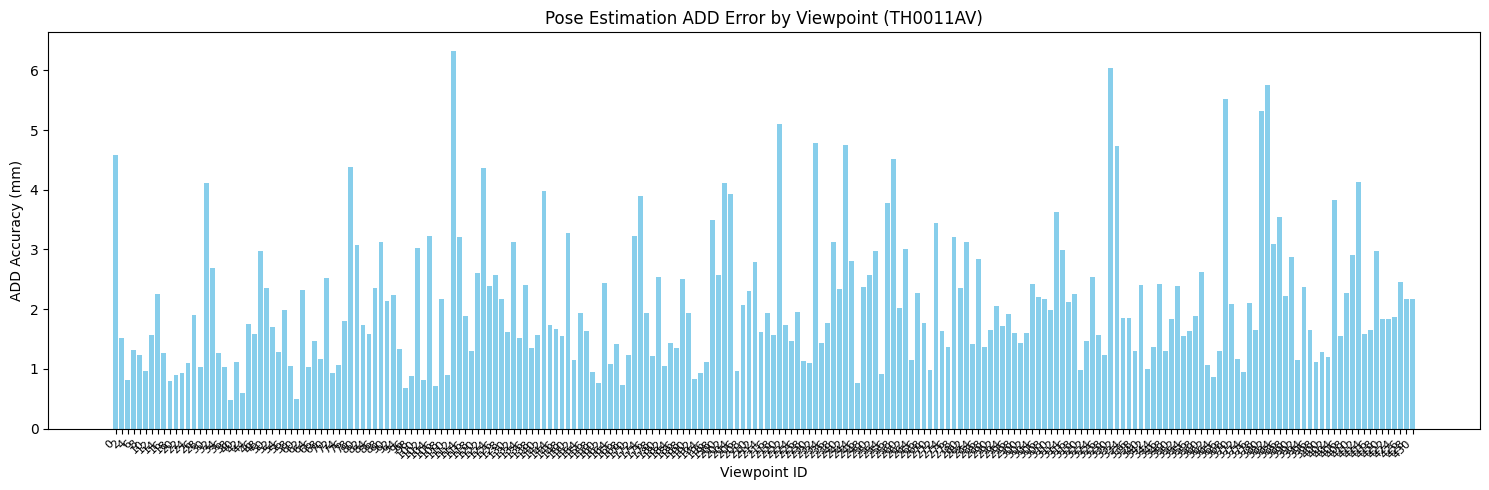

In [21]:
# ==========================================
# 7. SINGLE VIEW BENCHMARK (MULTIPLE VIEWPOINTS)
# ==========================================
import time
import copy
import pandas as pd
import numpy as np
import open3d as o3d
from scipy.spatial.transform import Rotation as R
import os
import matplotlib.pyplot as plt

TEST_WORKPIECE = "TH0011AV"

# Define the list of individual viewpoints you want to test independently
# For example: [0, 4, 8, 12, 16...] tests every 4th viewpoint
# TEST_VIEWPOINTS = list(range(0, 432, 4))
TEST_VIEWPOINTS = [
    0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38,
    40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78,
    80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 114, 116, 118,
    120, 122, 124, 126, 128, 130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154, 156, 158,
    160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180, 182, 184, 186, 188, 190, 192, 194, 196, 198,
    200, 202, 204, 206, 208, 210, 212, 214, 216, 218, 220, 222, 224, 226, 228, 230, 232, 234, 236, 238,
    240, 242, 244, 246, 248, 250, 252, 254, 256, 258, 260, 262, 264, 266, 268, 270, 272, 274, 276, 278,
    280, 282, 284, 286, 288, 290, 292, 294, 296, 298, 300, 302, 304, 306, 308, 310, 312, 314, 316, 318,
    320, 322, 324, 326, 328, 330, 332, 334, 336, 338, 340, 342, 344, 346, 348, 350, 352, 354, 356, 358,
    360, 362, 364, 366, 368, 370, 372, 374, 376, 378, 380, 382, 384, 386, 388, 390, 392, 394, 396, 398,
    400, 402, 404, 406, 408, 410, 412, 414, 416, 418, 420, 422, 424, 426, 428, 430
]

single_view_results = []

print(f"Starting Single View Benchmark for {TEST_WORKPIECE}")
print(f"Testing {len(TEST_VIEWPOINTS)} individual viewpoints...")
print(f"{'='*60}")

# Lock randomness
np.random.seed(42)
o3d.utility.random.seed(42)

source_path = f"workpiece/{TEST_WORKPIECE}/workpiece.stl"
data_dir = f"simulation/{EXPERIMENT}/{TEST_WORKPIECE}"

if not os.path.exists(source_path) or not os.path.exists(data_dir):
    print(f"Error: Missing STL or PCD folder for {TEST_WORKPIECE}!")
else:
    # 1. Load CAD
    mesh = o3d.io.read_triangle_mesh(source_path)
    mesh.compute_vertex_normals()
    source_cloud = mesh.sample_points_uniformly(number_of_points=NUMBER_OF_POINTS)
    
    # 3. Initial Guess
    T_extra = np.eye(4)
    r = R.from_euler('z', 0, degrees=True)
    T_extra[:3, :3] = r.as_matrix()
    T_initial_guess = T_base2ob_yolo @ T_extra
    
    # 4. Preprocess Source (Done once since it's the same for all views)
    source_cloud_transformed = copy.deepcopy(source_cloud).transform(T_initial_guess)
    source_down, source_fpfh = preprocess_normal(source_cloud_transformed)

    for v_idx in TEST_VIEWPOINTS:
        start_time = time.time()
        
        # 2. Load Scan (Only this specific viewpoint)
        full_target_cloud = merge_multiview_scan(data_dir, YOLO_POS, YOLO_ANGLE, CROP_BOX, viewpoint_indices=[v_idx], T_base2ob_yolo=T_base2ob_yolo, remove_plane=False, do_crop=False)
        
        if len(full_target_cloud.points) == 0:
             print(f"    [View {v_idx}] Skipped - No points found in target cloud!")
             continue
        if len(full_target_cloud.points) > FPS_NUMBER:
            full_target_cloud = full_target_cloud.farthest_point_down_sample(FPS_NUMBER)
             
        # 4. Preprocess Target
        target_down, target_fpfh = preprocess_normal(full_target_cloud, invert_normals=True)
        
        # 5. Global (RANSAC) - Optional
        if USE_RANSAC:
            ransac_res, best_thr = run_global_registration_adaptive(source_down, target_down, source_fpfh, target_fpfh)
            icp_initial = ransac_res.transformation
        else:
            icp_initial = np.eye(4)
            
        # 6. Local (ICP)
        FIXED_ICP_THRESHOLD = 2.0
        icp_res = o3d.pipelines.registration.registration_icp(
            source_down, target_down, FIXED_ICP_THRESHOLD, icp_initial,
            o3d.pipelines.registration.TransformationEstimationPointToPoint(),
            o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=200)
        )
        
        # 7. Evaluate
        T_est = np.dot(icp_res.transformation, T_initial_guess)
        add_value = calculate_add(source_cloud, T_est, T_gt)
        process_time = time.time() - start_time
        
        print(f"    [View {v_idx:3d}] ADD: {add_value:.4f} mm | Fitness: {icp_res.fitness:.4f} | Time: {process_time:.1f}s")
        
        single_view_results.append({
            'Viewpoint': v_idx,
            'ADD_Accuracy_mm': add_value,
            'Fitness': icp_res.fitness,
            'RMSE': icp_res.inlier_rmse,
            'Processing_Time_s': process_time
        })

if single_view_results:
    df_single = pd.DataFrame(single_view_results)
    print("\n\n" + "="*60)
    print("SINGLE VIEW BENCHMARK SUMMARY")
    print("="*60)
    
    # Sort by ADD Accuracy (best first)
    df_single_sorted = df_single.sort_values(by='ADD_Accuracy_mm', ascending=True).reset_index(drop=True)
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        display(df_single_sorted)
    
    mean_add = df_single['ADD_Accuracy_mm'].mean()
    print(f"\nAverage ADD across {len(single_view_results)} viewpoints: {mean_add:.4f} mm")
    
    # Plot the ADD Accuracy across all tested viewpoints
    plt.figure(figsize=(15, 5))
    plt.bar(df_single['Viewpoint'].astype(str), df_single['ADD_Accuracy_mm'], color='skyblue')
    plt.xlabel("Viewpoint ID")
    plt.ylabel("ADD Accuracy (mm)")
    plt.title(f"Pose Estimation ADD Error by Viewpoint ({TEST_WORKPIECE})")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()


In [79]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    # display(df_single_sorted)

# o3d.visualization.draw_geometries([source_est, source_gt, full_target_cloud], window_name=f"{wp} - 2. FINAL ICP RESULT (ADD: {add_value:.4f})")
o3d.visualization.draw_geometries([full_target_cloud], window_name=f"{wp} - 2. FINAL ICP RESULT (ADD: {add_value:.4f})")
